# AssignmentExperiment2: one-to-one assignment HOTA sweep

This notebook compares only enforced one-to-one frame assignment methods. Each simulated case is generated once per seed and difficulty level, the same detected peaks are reused for every method, and HOTA scores the resulting trajectories against the ground truth.

The methods compared are Hungarian, greedy one-to-one nearest neighbor, and mutual nearest neighbor. Permissive local/global NN baselines are intentionally excluded.

In [ ]:
from pathlib import Path
import os
import sys
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "Helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "Helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "Helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(exist_ok=True)

from Helpers.helpersSimulation import Simulator
from Helpers.helpersTracking import extract_peaks, track_peaks_to_trajectories
from Helpers.helpersStatistics import hota_only, TRUTH_MATCH_TOLERANCE_PX

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


## Settings

Difficulty increases by combining denser fields, more sub-positions per frame, stronger diffusion, and higher Poisson noise. The tracking mode is kept as integer-peak detection so the benchmark isolates the assignment solver rather than Gaussian localization quality.

In [2]:
ONE_TO_ONE_METHODS = ["hungarian", "greedy_nn", "mutual_nn"]
METHOD_LABELS = {
    "hungarian": "Hungarian",
    "greedy_nn": "Greedy 1-to-1 NN",
    "mutual_nn": "Mutual NN",
}
METHOD_COLORS = {
    "hungarian": "#2563eb",
    "greedy_nn": "#dc2626",
    "mutual_nn": "#16a34a",
}

SEEDS = list(range(5))

D_LIST_BASE = [
    (0.08, 0.14),
    (0.25, 0.14),
    (0.75, 0.16),
    (2.00, 0.18),
    (4.50, 0.22),
    (7.00, 0.16),
]

SIM_CONFIG_BASE = {
    "nparticles": 12,
    "nframes": 50,
    "nposframe": 4,
    "D_list": D_LIST_BASE,
    "dt": 1.0,
    "anisotropy_ratio_range": (0.85, 1.0),
    "theta_range": (0, np.pi),
    "frame_size": (128, 128),
    "intensity_mean": 700,
    "intensity_std": 180,
    "sigma_mean": 1.0,
    "sigma_std": 0.25,
    "boundary_margin": 14,
}

IMAGE_CONFIG_BASE = {
    "particle_intensity": [700, 180],
    "particle_sigma": [1.0, 0.25],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 3,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
    "use_trajectory_sigma": True,
}

DIFFICULTY_LEVELS = [
    {
        "difficulty_order": 1,
        "difficulty": "easy",
        "nparticles": 8,
        "nposframe": 2,
        "poisson_noise": 60,
        "D_multiplier": 0.70,
    },
    {
        "difficulty_order": 2,
        "difficulty": "medium",
        "nparticles": 12,
        "nposframe": 4,
        "poisson_noise": 100,
        "D_multiplier": 1.00,
    },
    {
        "difficulty_order": 3,
        "difficulty": "hard",
        "nparticles": 16,
        "nposframe": 6,
        "poisson_noise": 140,
        "D_multiplier": 1.25,
    },
    {
        "difficulty_order": 4,
        "difficulty": "very hard",
        "nparticles": 20,
        "nposframe": 8,
        "poisson_noise": 180,
        "D_multiplier": 1.50,
    },
]

TRACKING_KWARGS = {
    "mode": "detection",
    "detection_threshold": 400,
    "r_squared_threshold": 0.7,
    "max_distance": 10.0,
    "min_length": 5,
    "max_gap": 1,
}

RESULTS_PATH = OUT_DIR / "AssignmentExperiment2_hota_results.csv"
SUMMARY_PATH = OUT_DIR / "AssignmentExperiment2_hota_summary.csv"
FIGURE_PATH = OUT_DIR / "AssignmentExperiment2_hota_summary.png"

## Simulation and scoring helpers

In [3]:
def finite_mean(values):
    values = np.asarray(values, dtype=float).ravel()
    values = values[np.isfinite(values)]
    return float(np.mean(values)) if len(values) else np.nan


def finite_sem(values):
    values = np.asarray(values, dtype=float).ravel()
    values = values[np.isfinite(values)]
    if len(values) <= 1:
        return np.nan
    return float(np.std(values, ddof=1) / np.sqrt(len(values)))


def scaled_d_list(multiplier):
    return [(float(d) * float(multiplier), float(p)) for d, p in D_LIST_BASE]


def make_simulation(seed, difficulty):
    sim_cfg = copy.deepcopy(SIM_CONFIG_BASE)
    sim_cfg["nparticles"] = int(difficulty["nparticles"])
    sim_cfg["nposframe"] = int(difficulty["nposframe"])
    sim_cfg["D_list"] = scaled_d_list(difficulty["D_multiplier"])

    img_cfg = copy.deepcopy(IMAGE_CONFIG_BASE)
    img_cfg["poisson_noise"] = float(difficulty["poisson_noise"])

    sim = Simulator(sim_cfg, image_config=img_cfg, seed=seed).run()
    return sim, sim_cfg, img_cfg


def extract_peaks_once(sim):
    return extract_peaks(
        sim.frames,
        mode=TRACKING_KWARGS["mode"],
        detection_threshold=TRACKING_KWARGS["detection_threshold"],
        r_squared_threshold=TRACKING_KWARGS["r_squared_threshold"],
        verbose_loc=False,
        visualization_loc=False,
    )


def peak_count_summary(peaks):
    counts = np.asarray([len(frame_peaks) for frame_peaks in peaks], dtype=float)
    return {
        "total_peaks": int(np.sum(counts)),
        "mean_peaks_per_frame": finite_mean(counts),
    }


def track_with_assignment_algorithm(peaks, algorithm):
    return track_peaks_to_trajectories(
        peaks,
        max_distance=TRACKING_KWARGS["max_distance"],
        min_length=TRACKING_KWARGS["min_length"],
        algorithm=algorithm,
        cost_function=None,
        max_gap=TRACKING_KWARGS["max_gap"],
    )

## HOTA benchmark

HOTA is computed directly from the output trajectories. No permissive matching method is used in either tracking or scoring.

In [4]:
def summarize_results(results_df):
    metric_cols = [
        "hota",
        "deta",
        "assa",
        "tp",
        "fp",
        "fn",
        "runtime_s",
        "n_tracks",
        "total_peaks",
    ]
    rows = []

    group_cols = ["difficulty_order", "difficulty", "algo", "algo_label"]
    for keys, group in results_df.groupby(group_cols, sort=True):
        row = dict(zip(group_cols, keys))
        row["n"] = len(group)
        for metric in metric_cols:
            values = group[metric].to_numpy(dtype=float)
            row[f"{metric}_mean"] = finite_mean(values)
            row[f"{metric}_ci95"] = 1.96 * finite_sem(values)
        rows.append(row)

    return pd.DataFrame(rows).sort_values(["difficulty_order", "algo"])


def run_assignment_hota_experiment(
    seeds=SEEDS,
    difficulty_levels=DIFFICULTY_LEVELS,
    methods=ONE_TO_ONE_METHODS,
    force_rerun=True,
    verbose=True,
):
    if RESULTS_PATH.exists() and not force_rerun:
        results_df = pd.read_csv(RESULTS_PATH)
        summary_df = summarize_results(results_df)
        return results_df, summary_df

    rows = []
    total_cases = len(seeds) * len(difficulty_levels)
    case_idx = 0

    for difficulty in difficulty_levels:
        for seed in seeds:
            case_idx += 1
            sim, sim_cfg, img_cfg = make_simulation(seed, difficulty)
            peaks = extract_peaks_once(sim)
            peak_info = peak_count_summary(peaks)

            if verbose:
                print(
                    f"Case {case_idx}/{total_cases}: "
                    f"difficulty={difficulty['difficulty']}, seed={seed}, "
                    f"particles={sim_cfg['nparticles']}, peaks={peak_info['total_peaks']}"
                )

            for algo in methods:
                t0 = time.perf_counter()
                trajectories, cost_peak2peak = track_with_assignment_algorithm(peaks, algo)
                runtime_s = time.perf_counter() - t0

                metrics = hota_only(
                    trajectories,
                    sim.trajectories_GT,
                    tolerance_px=TRUTH_MATCH_TOLERANCE_PX,
                )

                rows.append({
                    "difficulty_order": int(difficulty["difficulty_order"]),
                    "difficulty": difficulty["difficulty"],
                    "seed": int(seed),
                    "algo": algo,
                    "algo_label": METHOD_LABELS[algo],
                    "hota": metrics["hota"],
                    "deta": metrics["deta"],
                    "assa": metrics["assa"],
                    "tp": metrics["tp"],
                    "fp": metrics["fp"],
                    "fn": metrics["fn"],
                    "runtime_s": float(runtime_s),
                    "mean_cost_peak2peak": finite_mean(cost_peak2peak),
                    "n_tracks": int(sum(traj.length() > 0 for traj in trajectories)),
                    "n_gt": int(len(sim.trajectories_GT)),
                    "nparticles": int(sim_cfg["nparticles"]),
                    "nframes": int(sim_cfg["nframes"]),
                    "nposframe": int(sim_cfg["nposframe"]),
                    "poisson_noise": float(img_cfg["poisson_noise"]),
                    "D_multiplier": float(difficulty["D_multiplier"]),
                    "truth_match_tolerance_px": float(TRUTH_MATCH_TOLERANCE_PX),
                    "tracking_max_distance": float(TRACKING_KWARGS["max_distance"]),
                    **peak_info,
                })

    results_df = pd.DataFrame(rows)
    summary_df = summarize_results(results_df)

    results_df.to_csv(RESULTS_PATH, index=False)
    summary_df.to_csv(SUMMARY_PATH, index=False)

    return results_df, summary_df

## Run

In [5]:
results_df, summary_df = run_assignment_hota_experiment(force_rerun=True, verbose=True)

summary_cols = [
    "difficulty",
    "algo_label",
    "n",
    "hota_mean",
    "hota_ci95",
    "deta_mean",
    "assa_mean",
    "runtime_s_mean",
    "n_tracks_mean",
]
display(summary_df[summary_cols].round(3))

Case 1/20: difficulty=easy, seed=0, particles=8, peaks=418
Case 2/20: difficulty=easy, seed=1, particles=8, peaks=399
Case 3/20: difficulty=easy, seed=2, particles=8, peaks=430
Case 4/20: difficulty=easy, seed=3, particles=8, peaks=401
Case 5/20: difficulty=easy, seed=4, particles=8, peaks=438
Case 6/20: difficulty=medium, seed=0, particles=12, peaks=527
Case 7/20: difficulty=medium, seed=1, particles=12, peaks=543
Case 8/20: difficulty=medium, seed=2, particles=12, peaks=539
Case 9/20: difficulty=medium, seed=3, particles=12, peaks=494
Case 10/20: difficulty=medium, seed=4, particles=12, peaks=502
Case 11/20: difficulty=hard, seed=0, particles=16, peaks=664
Case 12/20: difficulty=hard, seed=1, particles=16, peaks=663
Case 13/20: difficulty=hard, seed=2, particles=16, peaks=643
Case 14/20: difficulty=hard, seed=3, particles=16, peaks=670
Case 15/20: difficulty=hard, seed=4, particles=16, peaks=561
Case 16/20: difficulty=very hard, seed=0, particles=20, peaks=703
Case 17/20: difficulty=

,difficulty,algo_label,n,hota_mean,hota_ci95,deta_mean,assa_mean,runtime_s_mean,n_tracks_mean
0,easy,Greedy 1-to-1 NN,5,0.700,0.178,0.803,0.620,0.069,20.8
1,easy,Hungarian,5,0.710,0.170,0.803,0.635,0.076,19.6
2,easy,Mutual NN,5,0.700,0.178,0.803,0.620,0.069,20.8
3,medium,Greedy 1-to-1 NN,5,0.695,0.050,0.693,0.701,0.176,22.8
4,medium,Hungarian,5,0.697,0.071,0.693,0.705,0.194,22.2
5,medium,Mutual NN,5,0.695,0.050,0.693,0.701,0.161,22.8
6,hard,Greedy 1-to-1 NN,5,0.685,0.060,0.655,0.716,0.646,26.8
7,hard,Hungarian,5,0.691,0.061,0.657,0.727,0.746,26.6
8,hard,Mutual NN,5,0.685,0.060,0.655,0.716,0.651,26.8
9,very hard,Greedy 1-to-1 NN,5,0.650,0.049,0.539,0.786,0.400,25.6


## HOTA comparison

Saved figure: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AssignmentExperiment2_hota_summary.png


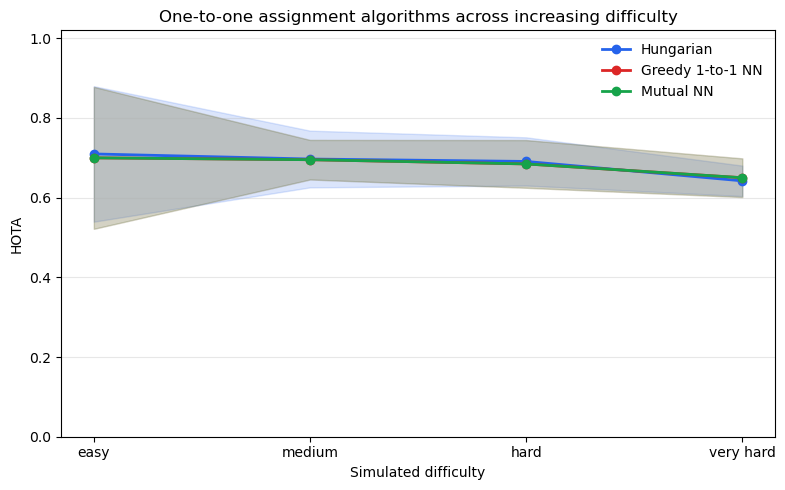

In [6]:
def plot_hota_by_difficulty(summary_df, save_path=FIGURE_PATH):
    fig, ax = plt.subplots(figsize=(8, 5))

    x_labels = (
        summary_df[["difficulty_order", "difficulty"]]
        .drop_duplicates()
        .sort_values("difficulty_order")
    )

    for algo in ONE_TO_ONE_METHODS:
        sub = summary_df[summary_df["algo"] == algo].sort_values("difficulty_order")
        x = sub["difficulty_order"].to_numpy(dtype=float)
        y = sub["hota_mean"].to_numpy(dtype=float)
        e = sub["hota_ci95"].fillna(0).to_numpy(dtype=float)

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            color=METHOD_COLORS[algo],
            label=METHOD_LABELS[algo],
        )
        ax.fill_between(x, y - e, y + e, color=METHOD_COLORS[algo], alpha=0.16)

    ax.set_xticks(x_labels["difficulty_order"].to_numpy(dtype=float))
    ax.set_xticklabels(x_labels["difficulty"].tolist())
    ax.set_xlabel("Simulated difficulty")
    ax.set_ylabel("HOTA")
    ax.set_ylim(0, 1.02)
    ax.set_title("One-to-one assignment algorithms across increasing difficulty")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(frameon=False)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {save_path}")

    return fig


fig = plot_hota_by_difficulty(summary_df)

## Saved outputs and configuration

In [7]:
print(f"Saved results: {RESULTS_PATH}")
print(f"Saved summary: {SUMMARY_PATH}")
print(f"Saved figure: {FIGURE_PATH}")

configuration_df = pd.DataFrame(DIFFICULTY_LEVELS)
display(configuration_df)

Saved results: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AssignmentExperiment2_hota_results.csv
Saved summary: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AssignmentExperiment2_hota_summary.csv
Saved figure: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AssignmentExperiment2_hota_summary.png


,difficulty_order,difficulty,nparticles,nposframe,poisson_noise,D_multiplier
0,1,easy,8,2,60,0.70
1,2,medium,12,4,100,1.00
2,3,hard,16,6,140,1.25
3,4,very hard,20,8,180,1.50
